### Architecture and Considerations

1. Data Pipeline
* **Dataset generation:** test only lower resolution 4:3 datasets
* **preprocessing** initial filters (Grant)

2. Model Selection
| Focus Area | Candidate Models | Considerations |
| :--- | :--- | :--- |
| **Aesthetic Quality** | NIMA, TANet, DINO, [TBD Model] | Evaluate for general aesthetic scoring. |
| **Technical Quality** | NIMA, [TBD Models] | Decide between using individual models or a single model with different fine-tuning targets (e.g., contrast vs. sharpness). |

* **Computational Metrics:** compute gflops and estimated latency with 1.4 TOPS of compute at 1 sample / sec

3. Pipeline Strategy
* **Technical Threshold:** Test different SPAQ models for the best performance, need to quanity this. May be good to add artificial noise and additional artifacting to test

* **Aesthetic Threshold:** Test different models to see their performance

* **Thresholding methods:** We need to consider a number of different methods for thresholding
* **Easy, Static Threshold:** Set an arbitrary cutoff for each
* **Preffered, Automatic Threshold:** Some sort of moving window that keeps images based on similar images. Ex, if there are lower scores the cutoff shrinks.

Many different strategies for this, some ideas off the top of my head
1. Weighted max score, set threshold as a percentage of the max score so far, this will likely increase over the course of a hike.
2. Percentile Threshold: alter threshold dynamically during a hike so roughly the same amount of images are saved over timescales. For example, roughly for every 10 minutes 1% of screenshots should be saved. This sounds like a good approach.

4. Visualization
* How can we visualize this process
* How can we quantify this process to improve it before deployment


## **TODO**

1. Need to add some sort of automatic blur to make sure SPAQ works right and can deal with poor inputs

2. Add preprocess filter options

3. Just test and tune more options

4. Try sequential data from a hike or walk around campus once models are shown to work

5. Create a scirpt combining both frameworks to see how they work in tandem

6. OPTIMIZE and create final edge framework to be put on OAK D using Luxonis API

In [2]:
#imports
from huggingface_hub import login
from datasets import load_dataset
from PIL import Image as PILImage # Aliased to avoid confusion with datasets.Image
import torch
import time
from torchvision import transforms
from torch.utils.data import DataLoader
import pyiqa
from scipy.stats import spearmanr, pearsonr
from ptflops import get_model_complexity_info
import pandas as pd
import datetime
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print(pyiqa.list_models())

['afine_all', 'afine_all_scale', 'afine_fr', 'afine_nr', 'ahiq', 'arniqa', 'arniqa-clive', 'arniqa-csiq', 'arniqa-flive', 'arniqa-kadid', 'arniqa-live', 'arniqa-spaq', 'arniqa-tid', 'brisque', 'brisque_matlab', 'ckdn', 'clipiqa', 'clipiqa+', 'clipiqa+_rn50_512', 'clipiqa+_vitL14_512', 'clipscore', 'cnniqa', 'compare2score', 'cw_ssim', 'dbcnn', 'deepdc', 'dists', 'dmm', 'entropy', 'fid', 'fid_dinov2', 'fsim', 'gmsd', 'hyperiqa', 'ilniqe', 'inception_score', 'laion_aes', 'liqe', 'liqe_mix', 'lpips', 'lpips+', 'lpips-vgg', 'lpips-vgg+', 'maclip', 'mad', 'maniqa', 'maniqa-kadid', 'maniqa-pipal', 'ms_ssim', 'msswd', 'musiq', 'musiq-ava', 'musiq-paq2piq', 'musiq-spaq', 'nima', 'nima-koniq', 'nima-spaq', 'nima-vgg16-ava', 'niqe', 'niqe_matlab', 'nlpd', 'nrqm', 'paq2piq', 'pi', 'pieapp', 'piqe', 'psnr', 'psnry', 'qalign', 'qalign_4bit', 'qalign_8bit', 'qualiclip', 'qualiclip+', 'qualiclip+-clive', 'qualiclip+-flive', 'qualiclip+-spaq', 'sfid', 'ssim', 'ssimc', 'stlpips', 'stlpips-vgg', 'topiq_

In [ ]:
# **CONFIGURATION**

# Easily changeable parameters

## Dataset Configuration
DATASET_SOURCES = [
    "ddecosmo/third-eye-augmented-hiking-dataset",
]
SPLIT = "test" #combine val and test?
BATCH_SIZE = 32

## Model Configuration
# Technical quality model (from pyiqa)
TECHNICAL_MODEL_NAME = 'nima-spaq'

# Aesthetic quality model options
AESTHETIC_MODEL_TYPE = 'hf_vgg16'  # options: 'dinov3', 'hf_mobilenet', 'hf_vgg16'
AESTHETIC_MODEL_CONFIG = {
    'dinov3': {
        'repo_id': "ddecosmo/dinov3-scenic-heads",
        'folder_label': "scenicOrNot_small_320x240",
        'model_prefix': "vit_s",  # 'vit_s', 'vit_s_plus', 'convnext_tiny'
        'head_type': "mlp"  # 'mlp' or 'msd'
    },
    'hf_mobilenet': {
        'repo_id': "ajawhar24/NIMA-MobileNetV2-ScenicOrNot-320x240",
        'filename': "pytorch_model.bin"
    },
    'hf_vgg16': {
        'repo_id': "ajawhar24/NIMA-VGG16-ScenicOrNot-320x240",
        'filename': "pytorch_model.bin"
    }
}

## Threshold Configuration
TECH_THRESHOLD_STRATEGY = 'static'
TECH_THRESHOLD_VALUE = 1  # 0-100 range

AES_THRESHOLD_STRATEGY = 'static'
AES_THRESHOLD_VALUE = 1  # 0-10 range

## Preprocessing Configuration
BLUR_THRESHOLD = 100
MIN_INTENSITY = 20
MAX_INTENSITY = 235

## Edge Compute Configuration
INPUT_RES = (3, 240, 320)
TOPS = 1.4
UTILIZATION = 0.3

## Storage Configuration
MEGAPIXELS = 13.0
MB_PER_MP = 0.35

# **FUNCTION SETUP**

In [5]:
def setup_tracking(hf_dataset, fps=1):
    num_samples = len(hf_dataset)

    # 1. Create the base tracking dictionary
    tracking_dict = {
        'image_index': range(num_samples),
        'technical_score': [None] * num_samples,
        'aesthetic_score': [None] * num_samples,
        'tech_threshold_applied': [None] * num_samples,
        'aes_threshold_applied': [None] * num_samples,
        'passed_prefilter': [0] * num_samples,
        'rejection_reason': [None] * num_samples,
        'passed_technical': [0] * num_samples,
        'passed_aesthetic': [0] * num_samples,
        'is_saved': [0] * num_samples
    }

    # 2. Automatically copy the ground truth 'score' if it exists in the dataset
    if 'score' in hf_dataset.features:
        tracking_dict['score'] = hf_dataset['score']
        print("Ground truth 'score' column detected and added to tracking log.")

    df = pd.DataFrame(tracking_dict)
    return df

In [6]:
#threshold functions
def static_threshold(score, threshold_value):
    """
    Simple pass/fail based on a fixed cutoff.

    Args:
        score (float): The predicted score from the model.
        threshold_value (float): The minimum score required to pass.

    Returns:
        bool: True if passed, False otherwise.
        float: The threshold applied (returned for logging purposes).
    """
    passed = score >= threshold_value
    return passed, threshold_value

def rolling_percentile_threshold(current_score, recent_scores, target_percentile=99):
    """
    Dynamic thresholding based on a rolling window of recent scores.
    For example, target_percentile=99 means it only keeps the top 1%
    relative to the recent window.

    Args:
        current_score (float): The predicted score for the current image.
        recent_scores (list or array): A list of scores from the last N images.
        target_percentile (float): The percentile rank required to pass (e.g., 90 for top 10%).

    Returns:
        bool: True if passed, False otherwise.
        float: The calculated threshold cutoff applied for this image.
    """
    # If the window isn't full yet (e.g., the very first few images),
    # we can either pass them all, fail them all, or use a default static threshold.
    # Here, we'll just accept them until we have enough data to calculate a percentile.
    if len(recent_scores) < 10:
        return True, 0.0

    # Calculate what the score cutoff is for the target percentile in the recent window
    cutoff_value = np.percentile(recent_scores, target_percentile)

    passed = current_score >= cutoff_value
    return passed, cutoff_value

def ema_threshold(current_score, current_ema, alpha=0.1, margin=0.5):
    """
    Uses an Exponential Moving Average to maintain a running baseline.
    Passes if the score is a certain margin above the EMA.

    Args:
        current_score (float): The predicted score.
        current_ema (float): The EMA calculated from the previous step.
        alpha (float): The smoothing factor (0 to 1). Higher = forgets older images faster.
        margin (float): The absolute value the score must be above the EMA to pass.
    """
    if current_ema is None:
        return True, 0.0 # Pass the first image

    cutoff_value = current_ema + margin
    passed = current_score >= cutoff_value

    return passed, cutoff_value

def percentage_of_max_threshold(current_score, max_score_so_far, percentage=0.90):
    """
    Threshold is a percentage of the highest score seen up to this point.

    Args:
        current_score (float): The predicted score for the current image.
        max_score_so_far (float): The highest score encountered in the run so far.
        percentage (float): The percentage multiplier (e.g., 0.90 for 90%).

    Returns:
        bool: True if passed, False otherwise.
        float: The calculated threshold cutoff applied.
    """
    # Update max score if the new score is higher (handled in main loop, but safety check here)
    if current_score > max_score_so_far:
        max_score_so_far = current_score

    cutoff_value = max_score_so_far * percentage
    passed = current_score >= cutoff_value

    return passed, cutoff_value

# Note: In your main loop, you would update the EMA *after* evaluating:
# new_ema = (current_score * alpha) + (current_ema * (1 - alpha))

# Map string names to your functions
THRESHOLD_REGISTRY = {
    'static': static_threshold,
    'rolling_percentile': rolling_percentile_threshold,
    'ema': ema_threshold,
    'percentage_of_max': percentage_of_max_threshold
}



In [7]:
#threshold class
class ThresholdManager:
    def __init__(self, strategy_name, **default_kwargs):
        """
        Initializes the threshold manager with a specific strategy and baseline parameters.
        """
        # Map string names to your functions (assuming THRESHOLD_REGISTRY is defined)
        if strategy_name not in THRESHOLD_REGISTRY:
            raise ValueError(f"Strategy '{strategy_name}' not found in registry.")

        self.strategy_name = strategy_name
        self.func = THRESHOLD_REGISTRY[strategy_name]

        # Extract window_size for rolling methods, keep the rest as default kwargs
        self.window_size = default_kwargs.pop('window_size', 100)
        self.default_kwargs = default_kwargs

        # --- Initialize Internal State Variables ---
        self.recent_scores = []
        self.current_ema = None
        self.max_score_so_far = 0.0

    def evaluate(self, current_score, **runtime_kwargs):
        """
        Evaluates the score against the chosen strategy.
        You can pass new parameters here to override the defaults on the fly.
        """
        # Merge default kwargs with any dynamic ones passed during this specific call
        active_kwargs = self.default_kwargs.copy()
        active_kwargs.update(runtime_kwargs)

        # 1. Route to the correct function based on strategy
        if self.strategy_name == 'static':
            passed, cutoff = self.func(current_score, **active_kwargs)

        elif self.strategy_name == 'rolling_percentile':
            passed, cutoff = self.func(current_score, self.recent_scores, **active_kwargs)

            # Update state: Add new score, trim window
            self.recent_scores.append(current_score)
            if len(self.recent_scores) > self.window_size:
                self.recent_scores.pop(0)

        elif self.strategy_name == 'ema':
            passed, cutoff = self.func(current_score, self.current_ema, **active_kwargs)

            # Update state: Calculate new EMA using the active alpha
            alpha = active_kwargs.get('alpha', 0.1)
            if self.current_ema is None:
                self.current_ema = current_score
            else:
                self.current_ema = (current_score * alpha) + (self.current_ema * (1 - alpha))

        elif self.strategy_name == 'percentage_of_max':
            passed, cutoff = self.func(current_score, self.max_score_so_far, **active_kwargs)

            # Update state: Check for a new all-time high
            if current_score > self.max_score_so_far:
                self.max_score_so_far = current_score

        return passed, cutoff

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import math
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

def plot_pipeline_funnel(df):
    total = len(df)
    pass_pre = df['passed_prefilter'].sum()
    pass_tech = df['passed_technical'].sum()
    pass_aes = df['is_saved'].sum()

    stages = ['Total', 'Pre-filter', 'Technical', 'Saved']
    counts = [total, pass_pre, pass_tech, pass_aes]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(stages, counts, color=['#cccccc', '#88ccee', '#44aa99', '#117733'])
    plt.title('Edge Pipeline Survival Rate', fontsize=16, fontweight='bold')

    for bar, count in zip(bars, counts):
        pct = (count / total) * 100
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (total*0.02),
                 f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')

    # Add breakdown of pre-filter failures as text
    fail_reasons = df[df['passed_prefilter'] == 0]['rejection_reason'].value_counts()
    if not fail_reasons.empty:
        reason_str = "Pre-filter Rejections:\n" + "\n".join([f"{k}: {v}" for k, v in fail_reasons.items()])
        plt.annotate(reason_str, xy=(0.5, 0.5), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))

    plt.tight_layout()
    plt.show()

def plot_rolling_thresholds(df, stage='aesthetic'):
    plt.figure(figsize=(14, 6))
    score_col = f'{stage}_score'
    prefix = 'aes' if stage == 'aesthetic' else 'tech'
    thresh_col = f'{prefix}_threshold_applied'

    valid_data = df[df[score_col].notnull()].copy()
    if len(valid_data) == 0:
        print(f"No score data available for '{stage}'.")
        return

    # Color nodes STRICTLY by the 'score' column
    if 'score' in valid_data.columns:
        # Force to float just in case the dataset stored them as strings
        valid_data['score'] = valid_data['score'].astype(float)

        # Plot each group separately so they appear neatly in the legend
        groups = [
            (1.0, 'green', 'Good (1.0)'),
            (0.5, 'gold', 'Mixed (0.5)'),
            (0.0, 'red', 'Bad (0.0)')
        ]

        for s_val, color, label in groups:
            subset = valid_data[valid_data['score'] == s_val]
            if len(subset) > 0:
                plt.scatter(subset.index, subset[score_col], color=color, label=label, s=25, alpha=0.8)
    else:
        # Fallback if 'score' column is missing from the dataframe
        plt.scatter(valid_data.index, valid_data[score_col], color='blue', label='Predicted Score', s=25, alpha=0.6)

    # Draw the dynamic threshold cutoff line
    if thresh_col in valid_data.columns:
        plt.plot(valid_data.index, valid_data[thresh_col], color='black', linewidth=2, linestyle='--', label='Cutoff Threshold')

    plt.title(f'{stage.capitalize()} Scores Over Time')
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_filter_distribution(df, stage='technical'):
    score_col = f'{stage}_score'
    valid_data = df[df[score_col].notnull()].copy()

    if len(valid_data) == 0:
        print(f"No data to plot for {stage}")
        return

    plt.figure(figsize=(10, 5))

    if 'score' in valid_data.columns:
        valid_data['score'] = valid_data['score'].astype(float)

        # Create a readable label column for the legend
        valid_data['Ground Truth'] = valid_data['score'].map({
            1.0: 'Good (1.0)', 0.5: 'Mixed (0.5)', 0.0: 'Bad (0.0)'
        })

        palette = {'Good (1.0)': 'green', 'Mixed (0.5)': 'gold', 'Bad (0.0)': 'red'}

        sns.histplot(data=valid_data, x=score_col, hue='Ground Truth',
                     palette=palette, multiple="stack", bins=40,
                     hue_order=['Good (1.0)', 'Mixed (0.5)', 'Bad (0.0)'])
        plt.title(f'{stage.capitalize()} Distribution (Colored by Ground Truth)')
    else:
        sns.histplot(data=valid_data, x=score_col, color='blue', bins=40)
        plt.title(f'{stage.capitalize()} Distribution')

    plt.show()

def view_sanity_check(hf_dataset, df, stage='aesthetic', status=1, num_images=5):
    col_name = f'passed_{stage}'
    subset = df[df[col_name] == status]

    if len(subset) == 0:
        print(f"No images found for {stage} == {status}")
        return

    num_samples = min(num_images, len(subset))
    sample_indices = subset.sample(num_samples)['image_index'].values
    cols = min(5, num_samples)
    rows = math.ceil(num_samples / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    if not isinstance(axes, (np.ndarray, list)): axes = [axes]
    else: axes = np.ravel(axes)

    plt.suptitle(f'Sanity Check: {stage.upper()} Status {status}', fontsize=16, fontweight='bold', y=1.02)

    for i, ax in enumerate(axes):
        if i < num_samples:
            idx = sample_indices[i]
            img = hf_dataset[int(idx)]['image']
            ax.imshow(img)
            reason = df.at[idx, 'rejection_reason'] if pd.notnull(df.at[idx, 'rejection_reason']) else ""
            ax.set_title(f"Idx: {idx} {reason}")
            ax.axis('off')
        else: ax.axis('off')
    plt.tight_layout()
    plt.show()

In [9]:
#edge compute function updated to include pre-filter
def profile_edge_compute(tech_model, aes_model, input_res=(3, 240, 320), tops=1.4, utilization=0.3):
    """
    Estimates the computational cost (GFLOPs) and latency of the pipeline, including pre-filter.
    """
    print("Profiling models... This may take a few seconds.")

    # 1. Models complexity
    raw_tech = tech_model.net if hasattr(tech_model, 'net') else tech_model
    raw_aes = aes_model.net if hasattr(aes_model, 'net') else aes_model

    tech_macs, tech_params = get_model_complexity_info(raw_tech, input_res, as_strings=False, print_per_layer_stat=False)
    aes_macs, aes_params = get_model_complexity_info(raw_aes, input_res, as_strings=False, print_per_layer_stat=False)

    tech_gflops = (tech_macs * 2) / (10**9)
    aes_gflops = (aes_macs * 2) / (10**9)

    # 2. Pre-filter estimation (OpenCV ops on CPU)
    # Grayscale + Mean + Laplacian is roughly 0.05 - 0.1 GFLOPs at this resolution
    prefilter_gflops = 0.08

    total_gflops = tech_gflops + aes_gflops + prefilter_gflops

    # 3. Latency calculation
    effective_gops = (tops * 1000) * utilization

    # Note: Pre-filter usually runs on CPU, so we estimate it separately (approx 2-5ms)
    prefilter_latency_ms = 3.5
    tech_latency_ms = (tech_gflops / effective_gops) * 1000
    aes_latency_ms = (aes_gflops / effective_gops) * 1000
    total_latency_ms = prefilter_latency_ms + tech_latency_ms + aes_latency_ms

    print("-" * 50)
    print(f"💻 HARDWARE PROFILE: {tops} TOPS NPU ({utilization*100:.0f}% Utilization)")
    print(f"📷 RESOLUTION: {input_res[2]}x{input_res[1]}")
    print("-" * 50)

    print(f"Pre-filter (CV):          {prefilter_gflops:.2f} GFLOPs | ~{prefilter_latency_ms} ms")
    print(f"Technical Filter (SPAQ):  {tech_gflops:.2f} GFLOPs | {tech_params / 10**6:.2f}M Params")
    print(f"Aesthetic Filter (AVA):   {aes_gflops:.2f} GFLOPs | {aes_params / 10**6:.2f}M Params")
    print(f"TOTAL PIPELINE COST:      {total_gflops:.2f} GFLOPs")
    print("-" * 50)

    print(f"Estimated Total Latency: {total_latency_ms:.1f} ms")

    max_fps = 1000 / total_latency_ms
    print(f"Maximum Theoretical FPS:        {max_fps:.1f} frames/sec")

    if max_fps >= 1.0:
        print("✅ Status: Meets the 1 sample/sec requirement.")
    else:
        print("❌ Status: FAILS the 1 sample/sec requirement.")

In [10]:
#storage estimate
def estimate_storage_requirements(df, megapixels=12.0, mb_per_mp=0.35):
    """
    Estimates the physical storage space required for the final saved images.

    Args:
        df: The Pandas tracking log DataFrame.
        megapixels: The resolution of the actual camera sensor in MP (e.g., 12.0).
        mb_per_mp: Estimated Megabytes per Megapixel after JPEG compression.
                   (Default 0.35 is a standard high-quality JPEG estimate).
    """
    saved_count = df['is_saved'].sum()
    total_images_seen = len(df)

    # Calculate sizes
    estimated_mb_per_image = megapixels * mb_per_mp
    total_storage_mb = saved_count * estimated_mb_per_image
    total_storage_gb = total_storage_mb / 1024

    print("💾 STORAGE ESTIMATE")
    print("=" * 30)
    print(f"Images Evaluated: {total_images_seen}")
    print(f"Images Saved:     {saved_count} ({(saved_count/total_images_seen)*100:.1f}% Keep Rate)")
    print("-" * 30)
    print(f"Camera Sensor:    {megapixels} MP")
    print(f"Size Per Image:   ~{estimated_mb_per_image:.2f} MB")
    print(f"Total Storage:    {total_storage_mb:.2f} MB ({total_storage_gb:.2f} GB)")
    print("=" * 30)

    return total_storage_mb

# Example usage:
# If deploying on a device with a 12MP camera:
# estimate_storage_requirements(tracking_log, megapixels=12.0)

# **INPUTS**

### **HUGGINGFACE LOGIN**

In [11]:
#hugging face login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### **DATASET**

TODO: add capability to read more than 1 dataset at a time and put them in series, should have score values already attached

In [12]:
from datasets import load_dataset, concatenate_datasets
import torch

# Load and merge datasets in series
print("🚀 Loading and concatenating datasets...")
datasets = [load_dataset(source, split=SPLIT) for source in DATASET_SOURCES]
dataset = concatenate_datasets(datasets)

# Initialize tracking and device
tracking_log = setup_tracking(dataset, fps=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Combined Dataset Size: {len(dataset)} images")
print(f"💻 Running on: {device.type.upper()}")

🚀 Loading and concatenating datasets...


README.md:   0%|          | 0.00/397 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/48.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/321 [00:00<?, ? examples/s]

Ground truth 'score' column detected and added to tracking log.
✅ Combined Dataset Size: 321 images
💻 Running on: CUDA


### **PREPROCESS**

In [13]:
def run_prefilter_on_dataset(hf_dataset, index, blur_thresh=BLUR_THRESHOLD, min_intensity=MIN_INTENSITY, max_intensity=MAX_INTENSITY):
    # Convert PIL to OpenCv format (Grayscale)
    pil_img = hf_dataset[index]['image']
    cv_img = np.array(pil_img.convert('L'))

    # 1. Lighting Check
    mean_intensity = np.mean(cv_img)
    if mean_intensity < min_intensity: return False, "Too Dark"
    if mean_intensity > max_intensity: return False, "Overexposed"

    # 2. Blur Check
    laplacian_var = cv2.Laplacian(cv_img, cv2.CV_64F).var()
    if laplacian_var < blur_thresh: return False, "Too Blurry"

    return True, "Passed"

### **THRESHOLDS**

In [14]:
# Thresholds
tech_thresholder = ThresholdManager(TECH_THRESHOLD_STRATEGY, threshold_value=TECH_THRESHOLD_VALUE)

aes_thresholder = ThresholdManager(AES_THRESHOLD_STRATEGY, threshold_value=AES_THRESHOLD_VALUE)

### **MODELS**

In [15]:
import torch
import torch.nn as nn
from huggingface_hub import hf_hub_download
import os

# ==========================================
# 1. MODEL ARCHITECTURES
# ==========================================
class MLPHead(nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int = 256, dropout_p: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

class MultiSampleDropoutHead(nn.Module):
    def __init__(self, embed_dim: int, dropout_p: float = 0.3, n_samples: int = 5):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(dropout_p) for _ in range(n_samples)])
        self.fc = nn.Linear(embed_dim, 1)
    def forward(self, x):
        preds = [self.fc(drop(x)) for drop in self.dropouts]
        return torch.stack(preds, dim=0).mean(dim=0).squeeze(-1)

class FullAestheticScorer(nn.Module):
    """Wraps the frozen backbone and trained head together into a single model."""
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head
    def forward(self, x):
        return self.head(self.backbone(x))

def load_huggingface_scorer(model_prefix, head_type, repo_id, folder_label, device):
    """
    Loads base weights from local environment, pulls trained head from HF, and merges them.
    """
    print(f"🧩 Assembling {model_prefix} + {head_type.upper()}...")

    # 1. Define the local filenames and the exact prefix used on HF
    meta_links = {
        "vit_s": {
            "file": "/content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth",
            "hf_prefix": "vit_s", # Matches vit_s_mlp_head.pth
        },
        "vit_s_plus": {
            "file": "/content/dinov3_vits16plus_pretrain_lvd1689m-4057cbaa.pth",
            "hf_prefix": "vit_s_plus",
        },
        "convnext_tiny": {
            "file": "/content/dinov3_convnext_tiny_pretrain_lvd1689m-21b726bb.pth",
            "hf_prefix": "ConvNeXt-Tiny (~28M)",
        }
    }

    if model_prefix not in meta_links:
        raise ValueError(f"Unknown model prefix! Choose from: {list(meta_links.keys())}")

    local_weights = meta_links[model_prefix]["file"]
    actual_hf_prefix = meta_links[model_prefix]["hf_prefix"]

    # 2. Verify base backbone weights exist in Colab
    if not os.path.exists(local_weights):
        raise FileNotFoundError(f"Base weights not found locally at {local_weights}. Please ensure they are uploaded to the Colab environment.")

    # 3. Load the frozen backbone via PyTorch Hub
    if model_prefix == "vit_s":
        backbone = torch.hub.load('facebookresearch/dinov3', 'dinov3_vits16', pretrained=False)
    elif model_prefix == "vit_s_plus":
        backbone = torch.hub.load('facebookresearch/dinov3', 'dinov3_vits16plus', pretrained=False)
    elif model_prefix == "convnext_tiny":
        backbone = torch.hub.load('facebookresearch/dinov3', 'dinov3_convnext_tiny', pretrained=False)

    backbone.load_state_dict(torch.load(local_weights, map_location='cpu'))
    backbone.eval()

    # 4. Dynamically get the embedding dimension
    with torch.no_grad():
        embed_dim = backbone(torch.randn(1, 3, 224, 224)).shape[-1]

    # 5. Initialize the correct head
    head = MLPHead(embed_dim) if head_type == "mlp" else MultiSampleDropoutHead(embed_dim)

    # 6. Download your trained head weights from Hugging Face
    hf_filename = f"{actual_hf_prefix}_{head_type}_head.pth"
    hf_path = f"{folder_label}/{hf_filename}" if folder_label else hf_filename

    print(f"☁️ Downloading custom head {hf_filename} from Hugging Face Hub...")
    local_head_path = hf_hub_download(repo_id=repo_id, filename=hf_path)
    head.load_state_dict(torch.load(local_head_path, map_location='cpu'))

    # 7. Wrap them together and push to target device
    scorer = FullAestheticScorer(backbone, head).to(device).eval()
    print("🚀 Ready for inference!\n")
    return scorer


In [16]:
# Install torchmetrics if needed for dinov3 models
!pip install torchmetrics -q

# Model loading is now handled in the config-based section below

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.4 MB/s eta 0:00:00


In [17]:
from huggingface_hub import hf_hub_download
import torch
import torch.nn as nn
import torchvision.models as models

class HFAestheticWrapper(torch.nn.Module):
    def __init__(self, repo_id, filename, device):
        super().__init__()

        # 1. Define architecture based on the regression output (1 neuron)
        if "MobileNetV2" in repo_id:
            self.net = models.mobilenet_v2(weights=None)
            self.net.classifier[1] = nn.Linear(self.net.last_channel, 1)
        elif "VGG16" in repo_id:
            self.net = models.vgg16(weights=None)
            self.net.classifier[6] = nn.Linear(4096, 1)

        # 2. Download and load weights
        weights_path = hf_hub_download(repo_id=repo_id, filename=filename)
        self.net.load_state_dict(torch.load(weights_path, map_location=device))
        self.net.to(device)
        self.net.eval()

    def forward(self, x):
        logits = self.net(x)
        return logits.squeeze(-1)

# Load Technical Model
print(f"Loading Technical Model: {TECHNICAL_MODEL_NAME}")
tech_model = pyiqa.create_metric(TECHNICAL_MODEL_NAME, device=device)

# Load Aesthetic Model based on config
if AESTHETIC_MODEL_TYPE == 'dinov3':
    config = AESTHETIC_MODEL_CONFIG['dinov3']
    aes_model = load_huggingface_scorer(
        model_prefix=config['model_prefix'],
        head_type=config['head_type'],
        repo_id=config['repo_id'],
        folder_label=config['folder_label'],
        device=device
    )
elif AESTHETIC_MODEL_TYPE in ['hf_mobilenet', 'hf_vgg16']:
    config = AESTHETIC_MODEL_CONFIG[AESTHETIC_MODEL_TYPE]
    aes_model = HFAestheticWrapper(config['repo_id'], config['filename'], device)
else:
    raise ValueError(f"Unknown aesthetic model type: {AESTHETIC_MODEL_TYPE}")


print("Models loaded successfully!")

Loading Technical Model: nima-spaq


model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/NIMA-spaq-46a7fcb7.pth" to /root/.cache/torch/hub/pyiqa/NIMA-spaq-46a7fcb7.pth



100%|██████████| 208M/208M [00:01<00:00, 188MB/s]


Loading pretrained model NIMA from /root/.cache/torch/hub/pyiqa/NIMA-spaq-46a7fcb7.pth


pytorch_model.bin:   0%|          | 0.00/537M [00:00<?, ?B/s]

Models loaded successfully!


In [18]:
# import torch
# import torch.nn as nn
# from transformers import Dinov2Model
# from huggingface_hub import hf_hub_download

# # Ensure device is mapped just like in your previous cells
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# class Dinov2AestheticScorer(nn.Module):
#     def __init__(self):
#         super().__init__()

#         # 1. Define the Head Architecture
#         class MLPHead(nn.Module):
#             def __init__(self, embed_dim=384, hidden_dim=256, dropout_p=0.3):
#                 super().__init__()
#                 self.net = nn.Sequential(
#                     nn.Linear(embed_dim, hidden_dim),
#                     nn.GELU(),
#                     nn.Dropout(dropout_p),
#                     nn.Linear(hidden_dim, 1),
#                 )
#             def forward(self, x):
#                 return self.net(x).squeeze(-1)

#         # 2. Load the base DINOv2 backbone
#         print("Loading DINOv2 backbone...")
#         self.backbone = Dinov2Model.from_pretrained("facebook/dinov2-small")

#         # 3. Load the pre-trained custom MLP head
#         print("Loading custom MLP head...")
#         self.head = MLPHead()
#         ckpt_path = hf_hub_download(repo_id="grantmwilkinson/dinov2-small-mlphead-aesthetic", filename="dinov2-small_MLPHead_best.pt")
#         self.head.load_state_dict(torch.load(ckpt_path, map_location="cpu", weights_only=True))

#     def forward(self, x):
#         # DINOv2 from the transformers library expects 'pixel_values'
#         # Extract the CLS token (index 0) from the last hidden state
#         features = self.backbone(pixel_values=x).last_hidden_state[:, 0]
#         # Pass features through the MLP head to get the score
#         scores = self.head(features)
#         return scores

# # Initialize the complete wrapped model and push it to CUDA (or CPU)
# aes_model = Dinov2AestheticScorer().to(device).eval()
# # Force the entire model (backbone + head) to the GPU
# aes_model = aes_model.to("cuda")

# # (Optional) Double check your tensors are also going to the right place in the loop:
# # aes_tensors = imagenet_norm(img_tensors).to("cuda")

# print(f"✅ aes_model successfully loaded and moved to {device}!")

In [28]:
aes_model = pyiqa.create_metric('nima', device=device)

Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/NIMA_InceptionV2_ava-b0c77c00.pth" to /root/.cache/torch/hub/pyiqa/NIMA_InceptionV2_ava-b0c77c00.pth



100%|██████████| 208M/208M [00:00<00:00, 344MB/s]


Loading pretrained model NIMA from /root/.cache/torch/hub/pyiqa/NIMA_InceptionV2_ava-b0c77c00.pth


# **RUNNING**

### NOTE:

This model actually computes scores for every single image in batches. This is not analogous to the actual implementation but allows for rapid inference during testing. It also still thresholds properly

In [29]:
import torchvision.transforms as transforms

# ==========================================
# PASS 1: HEAVY LIFT (Batched GPU Inference)
# ==========================================
print(f"Pass 1: Extracting raw scores for {len(dataset)} images in batches...")

# 1. Base transform: Restore exact training resolution (H=240, W=320)
img_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((240, 320)), # <--- THIS IS THE FIX
    transforms.ToTensor()
])

# 2. Specific Normalizer for DINOv3 / ConvNeXt
imagenet_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def transform_hf_batch(examples):
    examples["image"] = [img_transform(img) for img in examples["image"]]
    return examples

# 3. Apply the transform and strip non-tensor columns
inference_dataset = dataset.with_transform(transform_hf_batch)

dataloader = DataLoader(
    inference_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda batch: {'image': torch.stack([x['image'] for x in batch])}
)

# Put models in evaluation mode
tech_model.eval()
aes_model.eval()

current_idx = 0

with torch.inference_mode():
    for batch in tqdm(dataloader):
        # Base [0, 1] tensors for the technical model
        img_tensors = batch['image'].to(device)

        # 1. Technical Score (Expects [0, 1])
        tech_scores = tech_model(img_tensors).cpu().numpy()

        # 2. Aesthetic Score (pyiqa models expect [0, 1] normalized tensors directly)
        aes_scores = aes_model(img_tensors).cpu().numpy() # Removed imagenet_norm

        # Write to tracking_log
        for i in range(len(tech_scores)):
            tracking_log.at[current_idx, 'technical_score'] = float(tech_scores[i])
            tracking_log.at[current_idx, 'aesthetic_score'] = float(aes_scores[i])
            current_idx += 1

print("Pass 1 Complete! All raw scores saved.")

Pass 1: Extracting raw scores for 321 images in batches...


  0%|          | 0/11 [00:00<?, ?it/s]

/tmp/ipykernel_13494/3809878772.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tracking_log.at[current_idx, 'technical_score'] = float(tech_scores[i])
/tmp/ipykernel_13494/3809878772.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tracking_log.at[current_idx, 'aesthetic_score'] = float(aes_scores[i])


Pass 1 Complete! All raw scores saved.


In [30]:
# ==========================================
# PASS 2: EDGE SIMULATION (Updated with detailed logging)
# ==========================================
import cv2 # Ensure cv2 is available
print("Pass 2: Simulating edge threshold logic sequentially...")

for idx in tqdm(range(len(tracking_log))):
    passed_pre, reason = run_prefilter_on_dataset(dataset, idx)
    tracking_log.at[idx, 'passed_prefilter'] = int(passed_pre)

    if not passed_pre:
        tracking_log.at[idx, 'rejection_reason'] = reason
        tracking_log.at[idx, 'passed_technical'] = 0
        tracking_log.at[idx, 'passed_aesthetic'] = 0
        tracking_log.at[idx, 'is_saved'] = 0
        continue

    tech_score = tracking_log.at[idx, 'technical_score']
    passed_tech, tech_cutoff = tech_thresholder.evaluate(tech_score)
    tracking_log.at[idx, 'tech_threshold_applied'] = tech_cutoff
    tracking_log.at[idx, 'passed_technical'] = int(passed_tech)

    if passed_tech:
        aes_score = tracking_log.at[idx, 'aesthetic_score']
        passed_aes, aes_cutoff = aes_thresholder.evaluate(aes_score)
        tracking_log.at[idx, 'aes_threshold_applied'] = aes_cutoff
        tracking_log.at[idx, 'passed_aesthetic'] = int(passed_aes)
        if passed_aes: tracking_log.at[idx, 'is_saved'] = 1
    else:
        tracking_log.at[idx, 'passed_aesthetic'] = 0
        tracking_log.at[idx, 'is_saved'] = 0

print("Simulation complete!")

Pass 2: Simulating edge threshold logic sequentially...


  0%|          | 0/321 [00:00<?, ?it/s]

Simulation complete!


# **DATA ANALYSIS**

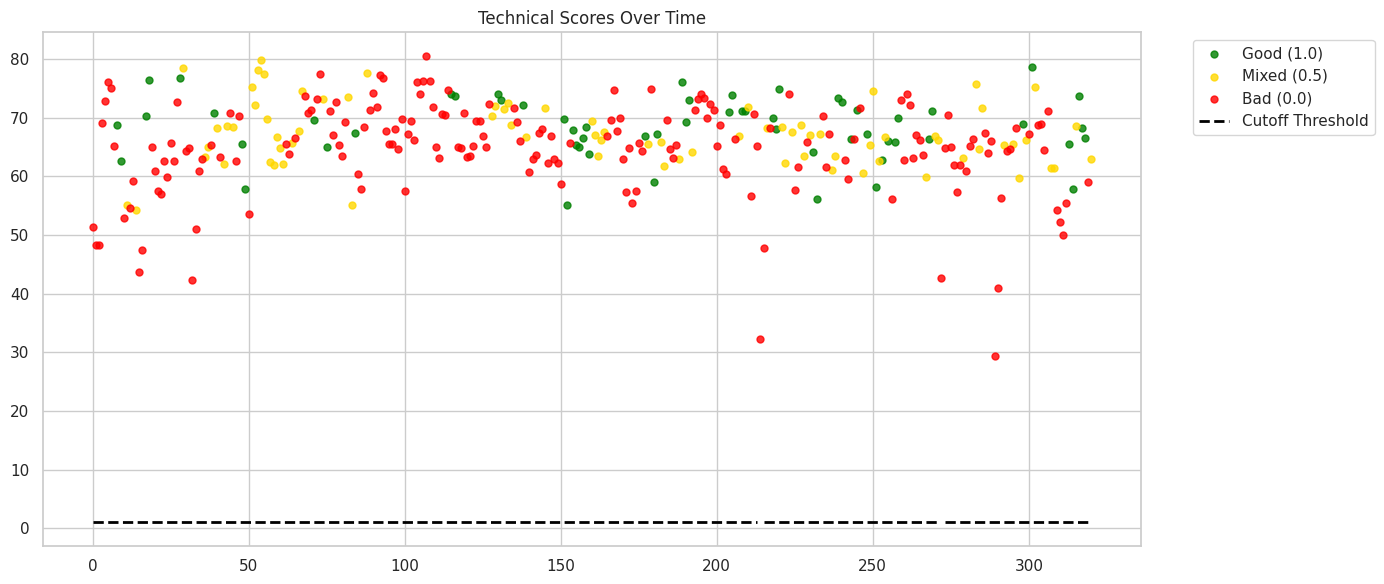

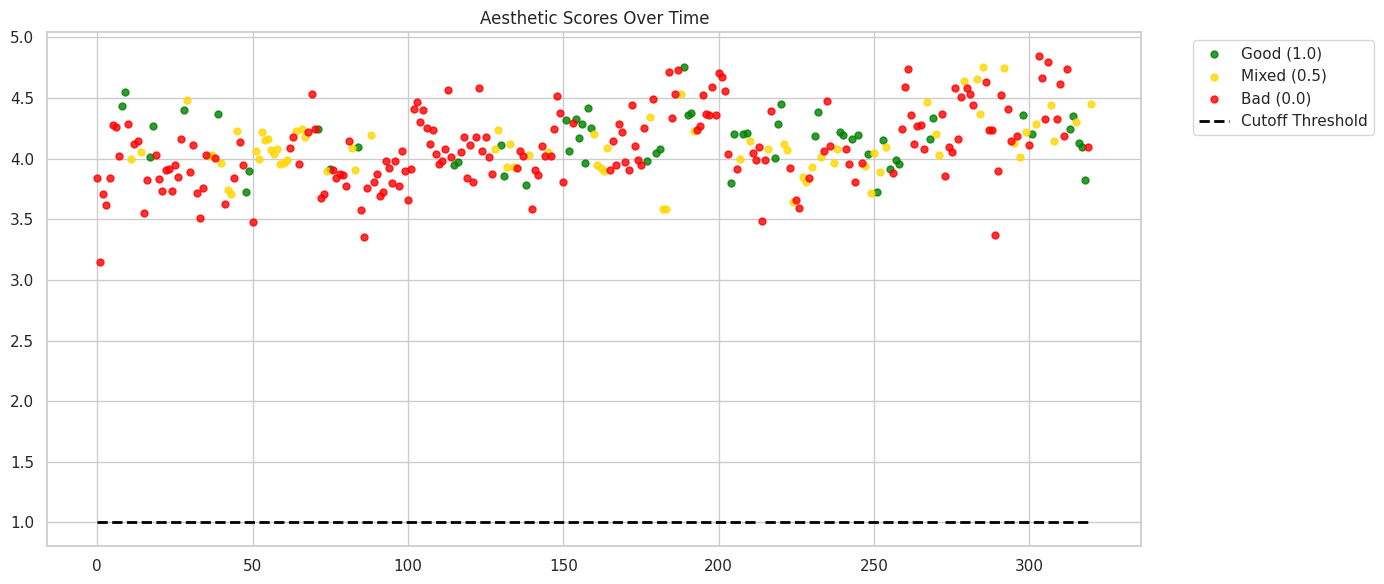

In [31]:
#display visualizations and metrics

#run visualization and data analysis functions to improve and understand trends

# 1. Look at your drop-off rates
# plot_pipeline_funnel(tracking_log)

#filter distributions 1
plot_rolling_thresholds(tracking_log, stage='technical')
plot_rolling_thresholds(tracking_log, stage='aesthetic')

# # filter distributions 2
# plot_filter_distribution(tracking_log, stage='aesthetic')
# plot_filter_distribution(tracking_log, stage='technical')




In [24]:
# # 3. Check 5 images that PASSED the aesthetic stage
# # 4. Check 5 images that FAILED the technical stage (blurry/bad lighting?)
# print("Preprocess BAD")
# view_sanity_check(dataset, tracking_log, stage='prefilter', status=0, num_images=5)


# print("Tech BAD")
# view_sanity_check(dataset, tracking_log, stage='technical', status=0, num_images=5)

# print("Aesthetic BAD")
# view_sanity_check(dataset, tracking_log, stage='aesthetic', status=0, num_images=5)

# print("GOOD")
# view_sanity_check(dataset, tracking_log, stage='aesthetic', status=1, num_images=5)


# **EDGE ANALYSIS**

In [25]:
# Run the profiler
profile_edge_compute(tech_model, aes_model, input_res=INPUT_RES, tops=TOPS, utilization=UTILIZATION)

Profiling models... This may take a few seconds.
--------------------------------------------------
💻 HARDWARE PROFILE: 1.4 TOPS NPU (30% Utilization)
📷 RESOLUTION: 320x240
--------------------------------------------------
Pre-filter (CV):          0.08 GFLOPs | ~3.5 ms
Technical Filter (SPAQ):  26.44 GFLOPs | 54.31M Params
Aesthetic Filter (AVA):   30.80 GFLOPs | 14.72M Params
TOTAL PIPELINE COST:      57.32 GFLOPs
--------------------------------------------------
Estimated Total Latency: 139.8 ms
Maximum Theoretical FPS:        7.2 frames/sec
✅ Status: Meets the 1 sample/sec requirement.


### **BASIC STORAGE ESTIMATE**

In [26]:
# Estimate storage
estimate_storage_requirements(tracking_log, megapixels=MEGAPIXELS, mb_per_mp=MB_PER_MP)

💾 STORAGE ESTIMATE
Images Evaluated: 321
Images Saved:     319 (99.4% Keep Rate)
------------------------------
Camera Sensor:    13.0 MP
Size Per Image:   ~4.55 MB
Total Storage:    1451.45 MB (1.42 GB)


np.float64(1451.45)

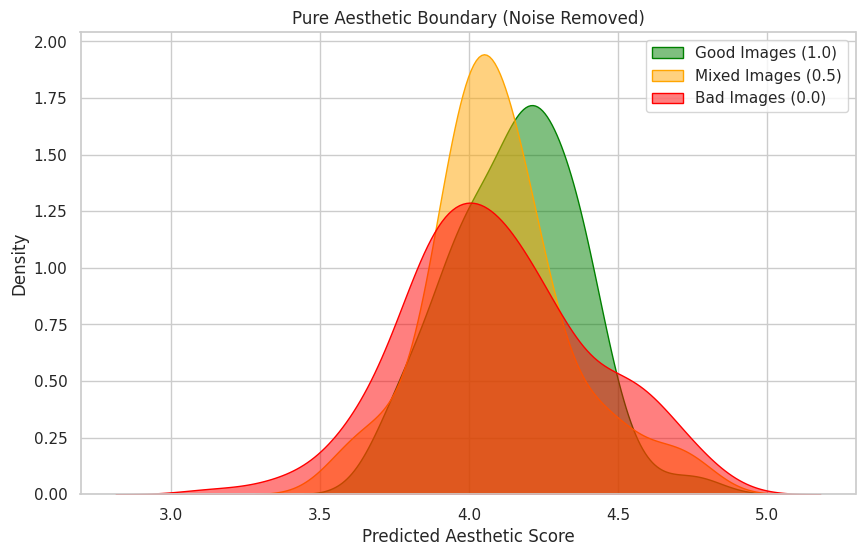


--- Aesthetic Score Means ---
Good (1.0) Mean:  4.1553
Mixed (0.5) Mean: 4.0994
Bad (0.0) Mean:   4.0946

--- Mean Differences ---
Good vs Bad Difference:   0.0607
Good vs Mixed Difference: 0.0558
Mixed vs Bad Difference:  0.0048
------------------------



In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_true_boundary(df, score_col='aesthetic_score',title = "Pure Aesthetic Boundary (Noise Removed)"):
    # 1. REMOVE the noise! Only look at images that passed the pre-filter
    clean_df = df[df['passed_prefilter'] == 1].copy()

    if len(clean_df) == 0:
        print("No images passed the prefilter!")
        return

    # Isolate the score series for each group
    good_scores = clean_df[clean_df['score'] == 1.0][score_col]
    mixed_scores = clean_df[clean_df['score'] == 0.5][score_col]
    bad_scores = clean_df[clean_df['score'] == 0.0][score_col]

    plt.figure(figsize=(10, 6))

    # 2. Plot the distributions based on ground truth 'score'
    # Adding checks to ensure the groups aren't empty before plotting
    if not good_scores.empty:
        sns.kdeplot(data=good_scores, color='green', fill=True, label='Good Images (1.0)', alpha=0.5)

    if not mixed_scores.empty:
        sns.kdeplot(data=mixed_scores, color='orange', fill=True, label='Mixed Images (0.5)', alpha=0.5)

    if not bad_scores.empty:
        sns.kdeplot(data=bad_scores, color='red', fill=True, label='Bad Images (0.0)', alpha=0.5)

    plt.title(title)
    plt.xlabel("Predicted Aesthetic Score")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    # 3. Compute and print the means and their differences
    mean_good = good_scores.mean() if not good_scores.empty else float('nan')
    mean_mixed = mixed_scores.mean() if not mixed_scores.empty else float('nan')
    mean_bad = bad_scores.mean() if not bad_scores.empty else float('nan')

    print("\n--- Aesthetic Score Means ---")
    print(f"Good (1.0) Mean:  {mean_good:.4f}")
    print(f"Mixed (0.5) Mean: {mean_mixed:.4f}")
    print(f"Bad (0.0) Mean:   {mean_bad:.4f}")

    print("\n--- Mean Differences ---")
    if pd.notna(mean_good) and pd.notna(mean_bad):
        print(f"Good vs Bad Difference:   {mean_good - mean_bad:.4f}")
    if pd.notna(mean_good) and pd.notna(mean_mixed):
        print(f"Good vs Mixed Difference: {mean_good - mean_mixed:.4f}")
    if pd.notna(mean_mixed) and pd.notna(mean_bad):
        print(f"Mixed vs Bad Difference:  {mean_mixed - mean_bad:.4f}")
    print("------------------------\n")

# Run this after your Edge Simulation Pass!
plot_true_boundary(tracking_log)

In [ ]:
plot_true_boundary(tracking_log, score_col='technical_score',title = "Technical Boundary")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_extreme_scores(tracking_df, dataset, x=5, highest=True, score_col='aes_score'):
    """
    Retrieves and displays the top X highest or lowest scoring images from the tracking log,
    loading images directly from the Hugging Face dataset.

    Args:
        tracking_df (pd.DataFrame): The dataframe containing your image indices and scores.
        dataset: The Hugging Face dataset object from which to load images.
        x (int): Number of images to retrieve.
        highest (bool): If True, gets the highest scores. If False, gets the lowest.
        score_col (str): The name of the column containing the aesthetic scores.

    Returns:
        pd.DataFrame: A dataframe containing just the top X results.
    """
    # Sort the dataframe.
    sorted_df = tracking_df.sort_values(by=score_col, ascending=not highest).head(x)

    # Set up the matplotlib figure
    fig, axes = plt.subplots(1, x, figsize=(3 * x, 4))

    # Handle the edge case where x=1 (axes is not a list in this case)
    if x == 1:
        axes = [axes]
    elif x == 0:
        print("No images to display.")
        plt.close(fig) # Close empty figure
        return pd.DataFrame()

    print(f"Showing Top {x} {'Highest' if highest else 'Lowest'} Scoring Images:")

    for ax, (_, row) in zip(axes, sorted_df.iterrows()):
        img_idx = int(row['image_index']) # Get the original index from the tracking log
        predicted_score = row[score_col]
        ground_truth_score = row['score'] # Get the ground truth score

        # Print to console
        print(f"  Image Index: {img_idx}, Predicted Score: {predicted_score:.2f}, Ground Truth Score: {ground_truth_score:.1f}")

        try:
            # Load the image directly from the Hugging Face dataset
            img = dataset[img_idx]['image']
            ax.imshow(img)
            ax.set_title(f"Pred: {predicted_score:.2f}\nGT: {ground_truth_score:.1f}") # Display both scores
            ax.axis('off')
        except Exception as e:
            ax.set_title(f"Error loading img\nPred: {predicted_score:.2f}\nGT: {ground_truth_score:.1f}")
            ax.axis('off')
            print(f"Could not load image at index {img_idx}: {e}")

    plt.tight_layout()
    plt.show()

    return sorted_df

In [ ]:
# ==========================================
# HOW TO USE IT:
# ==========================================

# Assuming your 'tracking_log' is a list of dictionaries from the Pass 1 loop,
# first convert it to a DataFrame if you haven't already:
#df_log = pd.DataFrame(tracking_log)

# Ensure df_log is properly initialized if not already, or use tracking_log directly
df_log = tracking_log.copy() # Make a copy to work with

# The 'path' column is no longer needed since images are loaded directly from the dataset
# df_log['path'] = [dataset[i]['filename'] for i in df_log['image_index']]

# Get the 5 BEST images
best_images = show_extreme_scores(df_log, dataset, x=10, highest=True, score_col='aesthetic_score')

# Get the 5 WORST images
worst_images = show_extreme_scores(df_log, dataset, x=10, highest=False, score_col='aesthetic_score')

In [ ]:
# ==========================================
# HOW TO USE IT:
# ==========================================

# Assuming your 'tracking_log' is a list of dictionaries from the Pass 1 loop,
# first convert it to a DataFrame if you haven't already:
#df_log = pd.DataFrame(tracking_log)

# Ensure df_log is properly initialized if not already, or use tracking_log directly
df_log = tracking_log.copy() # Make a copy to work with

# The 'path' column is no longer needed since images are loaded directly from the dataset
# df_log['path'] = [dataset[i]['filename'] for i in df_log['image_index']]

# Get the 5 BEST images
best_images = show_extreme_scores(df_log, dataset, x=5, highest=True, score_col='aesthetic_score')

# Get the 5 WORST images
worst_images = show_extreme_scores(df_log, dataset, x=5, highest=False, score_col='aesthetic_score')

In [ ]:
print("Displaying the head of tracking_log to show the 'score' column:")
display(tracking_log.head())